# DP-FedAvg Impact Analysis for FL-IMDR

This notebook runs a controlled ablation of the risk-learning layer to quantify how the implemented server-side Gaussian perturbation affects:

- global risk-prediction accuracy,
- empirical convergence speed,
- predictive disparity across insurers, and
- predictive disparity across patient risk quartiles.

The experiment follows the manuscript/repository setting of **100 patients, 4 heterogeneous insurers, 120 monthly rounds, 50 common random seeds, federation every 10 rounds, and client-update clipping at $C=1$**. The patient risk function and stochastic state evolution follow the repository definitions. A compact federated risk head is used so the effect of DP noise can be isolated and reproduced quickly. The tested noise scales are $\sigma_{\mathrm{DP}}\in\{0,0.01,0.05,0.10\}$.

The experiment analyzes the noise scale directly. Converting it to a cumulative $(arepsilon,\delta)$ guarantee requires a specified neighboring relation and privacy accountant.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

OUT = Path('dp_fedavg_appendix')
OUT.mkdir(exist_ok=True)
print('Output directory:', OUT.resolve())

Output directory: /mnt/data/dp_fedavg_appendix


## Mathematical quantities

At federation event $k$, insurer $j$ sends the clipped update

$$
ar\Delta_{j,k}=\Delta_{j,k}\min\left(1,rac{C}{\|\Delta_{j,k}\|_2}ight),
$$

and the server performs

$$
\phi_{k+1}=\phi_k+\sum_jlpha_{j,k}ar\Delta_{j,k}+\zeta_k,
\qquad \zeta_k\sim\mathcal N(0,\sigma_{\mathrm{DP}}^2I).
$$

Since $\mathbb E[\zeta_k]=0$ but $\mathbb E\|\zeta_k\|_2^2=d\sigma_{\mathrm{DP}}^2$, the Gaussian term adds no direct mean shift but increases update variance. Clipping can additionally introduce bias when an update norm exceeds $C$.

Fairness is measured as predictive disparity:

$$
\Delta_{\mathrm{ins}}=\max_j \mathrm{MSE}_j-\min_j \mathrm{MSE}_j,
\qquad
\Delta_{\mathrm{grp}}=\max_q \mathrm{MSE}_q-\min_q \mathrm{MSE}_q,
$$

where $q$ indexes baseline latent-risk quartiles.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

SIGMAS = [0.0, 0.01, 0.05, 0.10]
N_PATIENTS = 100
N_INSURERS = 4
T = 120
FED_INTERVAL = 10
CLIP_C = 1.0
LOCAL_STEPS = 3
LR = 0.08
N_SEEDS = 50


def rng_patient_state(rng, n):
    age = rng.integers(18, 70, size=n).astype(float)
    # The repository uses np.random.normal(20_000, 120_000), then later clips dynamics.
    # We use a bounded positive initialization to avoid nonphysical negative incomes.
    income = np.clip(rng.normal(70_000, 25_000, size=n), 10_000, 200_000)
    credit = rng.uniform(300, 850, size=n)
    health = rng.beta(4, 2, size=n)
    location = rng.uniform(0, 1, size=n)
    return age, income, credit, health, location


def actual_risk(age, income, credit, health, rng):
    h = np.clip(health, 0, 1)
    c = np.clip(credit / 850.0, 0, 1)
    a = np.clip(age / 100.0, 0, 1)
    y = np.clip(income / 120_000.0, 0, 1)
    health_factor = np.exp(-3.0 * h)
    credit_factor = (1.0 - c) ** 2
    age_factor = a ** 2 + 0.2 * a
    social_factor = 1.0 - 0.2 * y
    base = social_factor * health_factor * (0.5 * credit_factor + 0.5 * age_factor)
    eps = rng.normal(0.0, 0.05, size=len(age))
    return np.clip(base * (1.0 + eps), 0.0, 1.0)


def features(age, income, credit, health, location):
    a = np.clip(age / 70.0, 0, 1.5)
    y = np.clip(income / 120_000.0, 0, 1.7)
    c = np.clip(credit / 850.0, 0, 1)
    h = np.clip(health, 0, 1)
    l = np.clip(location, 0, 1)
    X = np.column_stack([
        np.ones_like(a), a, y, c, h, l,
        a*a, (1-c)**2, h*h, a*h, y*h,
    ])
    return X


def evolve(age, income, credit, health, base_income, base_credit, base_health, rng):
    income += 0.05 * (base_income - income) + 0.05 * base_income * rng.normal(size=len(age))
    health += 0.05 * (base_health - health) + 0.05 * rng.normal(size=len(age))
    credit += 0.05 * (base_credit - credit) + 0.03 * base_credit * rng.normal(size=len(age))
    age = np.minimum(age + 1.0, 100.0)
    income = np.clip(income, 10_000, 200_000)
    health = np.clip(health, 0, 1)
    credit = np.clip(credit, 300, 850)
    return age, income, credit, health


def predict(X, w):
    return np.clip(X @ w, 0.0, 1.0)


def mse(y, yh):
    return float(np.mean((y-yh)**2)) if len(y) else np.nan


def convergence_month(curve):
    curve = np.asarray(curve, float)
    smooth = pd.Series(curve).rolling(5, min_periods=1).mean().to_numpy()
    init = np.nanmean(smooth[:5])
    final = np.nanmean(smooth[-10:])
    if not np.isfinite(init) or not np.isfinite(final):
        return np.nan
    # 90% of the observed reduction; if no reduction, use a 5% final-value band.
    if init > final:
        threshold = final + 0.10 * (init-final)
        candidates = np.where(smooth <= threshold)[0]
    else:
        tol = 0.05 * max(abs(final), 1e-8)
        candidates = np.where(np.abs(smooth-final) <= tol)[0]
    for idx in candidates:
        end = min(len(smooth), idx+5)
        if end-idx >= 3 and np.all(np.isfinite(smooth[idx:end])):
            return int(idx+1)
    return int(len(curve))


def run_one(seed, sigma):
    # Common random numbers across sigma values: all exogenous randomness uses rng_env.
    # DP randomness uses a separate stream that depends on sigma only through its scale.
    rng_env = np.random.default_rng(seed)
    rng_dp = np.random.default_rng(100_000 + seed)

    age, income, credit, health, location = rng_patient_state(rng_env, N_PATIENTS)
    base_income, base_credit, base_health = income.copy(), credit.copy(), health.copy()
    wanted = rng_env.uniform(0.1, 0.9, size=N_PATIENTS)
    budget_frac = rng_env.uniform(0.07, 0.2, size=N_PATIENTS)
    risk0 = actual_risk(age, income, credit, health, rng_env)
    quartile_edges = np.quantile(risk0, [0.25, 0.5, 0.75])
    risk_group = np.digitize(risk0, quartile_edges, right=True)

    d = features(age, income, credit, health, location).shape[1]
    w_global = rng_env.normal(0, 0.02, size=d)
    w_local = np.tile(w_global, (N_INSURERS, 1))

    # Heterogeneous insurer attitudes induce non-IID selection.
    markup = np.array([-0.05, 0.00, 0.04, 0.08])
    risk_load = np.array([0.25, 0.45, -0.10, 0.65])
    coverage_bias = np.array([0.06, 0.00, -0.03, 0.03])
    assignment = rng_env.integers(0, N_INSURERS, size=N_PATIENTS)

    records = []
    for t in range(T):
        if t > 0:
            age, income, credit, health = evolve(
                age, income, credit, health,
                base_income, base_credit, base_health, rng_env
            )
        y = actual_risk(age, income, credit, health, rng_env)
        X = features(age, income, credit, health, location)
        budget = income * budget_frac

        # Market selection from insurer-specific risk predictions.
        preds = np.column_stack([predict(X, w_local[j]) for j in range(N_INSURERS)])
        price = np.empty_like(preds)
        cov = np.empty_like(preds)
        utility = np.empty_like(preds)
        for j in range(N_INSURERS):
            burden = np.clip(0.52 + markup[j] + risk_load[j]*(preds[:, j]-0.25), 0.20, 1.20)
            price[:, j] = budget * burden
            cov[:, j] = np.clip(0.72 + coverage_bias[j] - 0.25*preds[:, j], 0.10, 1.0)
            value = budget / np.maximum(wanted, 1e-3)
            utility[:, j] = value*cov[:, j] - price[:, j] - 0.10*value*np.maximum(wanted-cov[:, j], 0)

        best = np.argmax(utility, axis=1)
        # Switching inertia mirrors the repository's switch probability.
        switch = rng_env.random(N_PATIENTS) < 0.5
        assignment = np.where(switch, best, assignment)

        # Local full-batch gradient steps on the insurer's selected population.
        client_sizes = np.zeros(N_INSURERS, dtype=int)
        for j in range(N_INSURERS):
            idx = np.where(assignment == j)[0]
            client_sizes[j] = len(idx)
            if len(idx) == 0:
                continue
            Xj, yj = X[idx], y[idx]
            for _ in range(LOCAL_STEPS):
                pred = Xj @ w_local[j]
                grad = 2.0 * (Xj.T @ (pred-yj)) / len(idx)
                w_local[j] -= LR * grad

        # Federation every K rounds: client-level clipping + server Gaussian noise.
        if (t+1) % FED_INTERVAL == 0:
            deltas = w_local - w_global
            norms = np.linalg.norm(deltas, axis=1)
            scales = np.minimum(1.0, CLIP_C / np.maximum(norms, 1e-12))
            clipped = deltas * scales[:, None]
            weights = np.maximum(client_sizes, 1).astype(float)
            weights /= weights.sum()
            avg_delta = np.sum(weights[:, None] * clipped, axis=0)
            noise = rng_dp.normal(0.0, sigma, size=d)
            w_global = w_global + avg_delta + noise
            w_local[:] = w_global

        # Evaluate global model on the entire population.
        yhat_g = predict(X, w_global)
        global_mse = mse(y, yhat_g)
        # Evaluate each insurer model on the same market population so the
        # disparity is not confounded by different client-set sizes.
        insurer_mses = [mse(y, predict(X, w_local[j])) for j in range(N_INSURERS)]
        group_mses = []
        for g in range(4):
            idx = np.where(risk_group == g)[0]
            group_mses.append(mse(y[idx], yhat_g[idx]))
        records.append({
            'seed': seed, 'sigma': sigma, 'month': t+1,
            'global_mse': global_mse,
            'insurer_gap': float(np.nanmax(insurer_mses)-np.nanmin(insurer_mses)),
            'group_gap': float(np.nanmax(group_mses)-np.nanmin(group_mses)),
            'worst_group_mse': float(np.nanmax(group_mses)),
        })
    return records


def run_all():
    rows = []
    for seed in range(N_SEEDS):
        for sigma in SIGMAS:
            rows.extend(run_one(seed, sigma))
    raw = pd.DataFrame(rows)
    return raw


def summarize(raw):
    summaries = []
    for (seed, sigma), g in raw.groupby(['seed','sigma']):
        summaries.append({
            'seed': seed,
            'sigma': sigma,
            'final_mse': g['global_mse'].tail(10).mean(),
            'mse_auc': np.trapezoid(g['global_mse'], x=g['month']) / (T-1),
            'convergence_month': convergence_month(g['global_mse'].to_numpy()),
            'insurer_gap': g['insurer_gap'].tail(10).mean(),
            'group_gap': g['group_gap'].tail(10).mean(),
            'worst_group_mse': g['worst_group_mse'].tail(10).mean(),
        })
    per_seed = pd.DataFrame(summaries)
    agg = per_seed.groupby('sigma').agg(['mean','std']).reset_index()
    agg.columns = ['sigma'] + [f'{a}_{b}' for a,b in agg.columns.tolist()[1:]]
    return per_seed, agg



In [3]:
raw = run_all()
per_seed, summary = summarize(raw)
raw.to_csv(OUT / 'dp_raw_timeseries.csv', index=False)
per_seed.to_csv(OUT / 'dp_per_seed_summary.csv', index=False)
summary.to_csv(OUT / 'dp_summary.csv', index=False)
summary

,sigma,seed_mean,seed_std,final_mse_mean,final_mse_std,mse_auc_mean,mse_auc_std,convergence_month_mean,convergence_month_std,insurer_gap_mean,insurer_gap_std,group_gap_mean,group_gap_std,worst_group_mse_mean,worst_group_mse_std
0,0.00,24.5,14.57738,0.001251,0.000473,0.001453,0.000302,25.18,30.092843,0.000040,0.000037,0.002755,0.001633,0.003184,0.001669
1,0.01,24.5,14.57738,0.002503,0.001981,0.002255,0.000396,36.78,40.410289,0.001173,0.001964,0.002941,0.001665,0.004431,0.002305
2,0.05,24.5,14.57738,0.028387,0.049643,0.017177,0.007249,68.00,40.214222,0.024271,0.049830,0.013359,0.011360,0.035521,0.052009
3,0.10,24.5,14.57738,0.092518,0.166858,0.056410,0.027741,72.08,37.653002,0.081403,0.167146,0.034873,0.038175,0.109540,0.176522


## Figure A1 — Global risk-prediction MSE

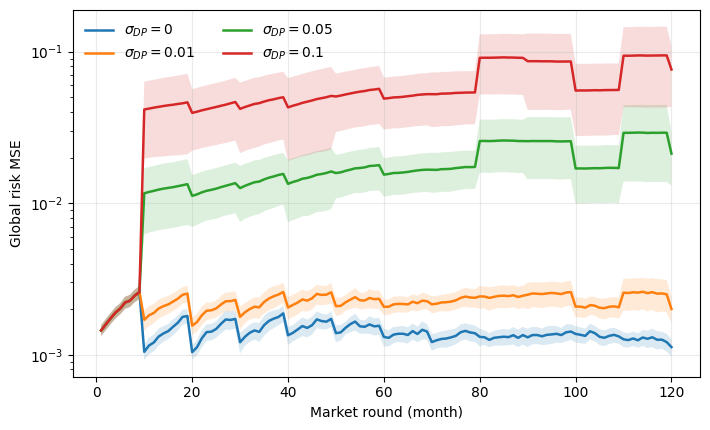

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for sigma, g in raw.groupby('sigma'):
    s = g.groupby('month')['global_mse'].agg(['mean','std','count']).reset_index()
    ci = 1.96 * s['std'] / np.sqrt(s['count'])
    line, = ax.plot(s['month'], s['mean'], linewidth=1.8, label=fr'$\sigma_{{DP}}={sigma:g}$')
    ax.fill_between(s['month'], s['mean']-ci, s['mean']+ci, alpha=0.16)
ax.set_xlabel('Market round (month)')
ax.set_ylabel('Global risk MSE')
ax.set_yscale('log')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUT / 'dp_accuracy.pdf', bbox_inches='tight')
fig.savefig(OUT / 'dp_accuracy.png', dpi=600, bbox_inches='tight')
plt.show()

## Figure A2 — Empirical convergence month

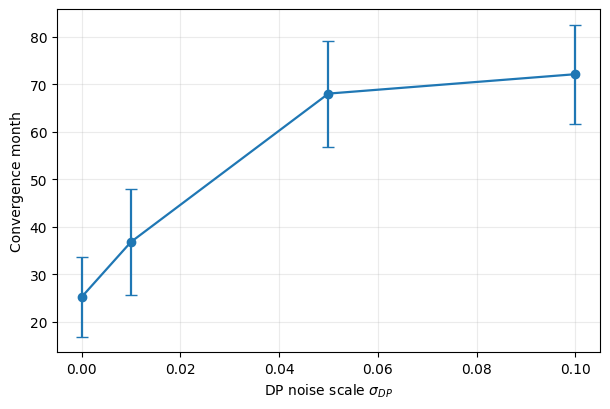

In [5]:
c = per_seed.groupby('sigma')['convergence_month'].agg(['mean','std','count']).reset_index()
ci = 1.96*c['std']/np.sqrt(c['count'])
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(c['sigma'], c['mean'], yerr=ci, marker='o', capsize=4, linewidth=1.6)
ax.set_xlabel(r'DP noise scale $\sigma_{DP}$')
ax.set_ylabel('Convergence month')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'dp_convergence.pdf', bbox_inches='tight')
fig.savefig(OUT / 'dp_convergence.png', dpi=600, bbox_inches='tight')
plt.show()

## Figure A3 — Predictive fairness gaps

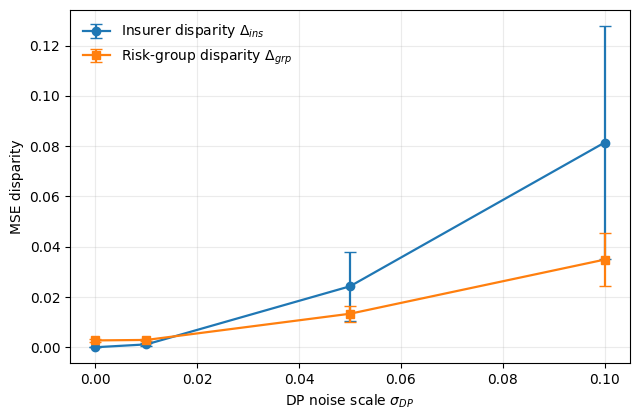

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.3))
for metric, label, marker in [
    ('insurer_gap', r'Insurer disparity $\Delta_{ins}$', 'o'),
    ('group_gap', r'Risk-group disparity $\Delta_{grp}$', 's')]:
    s = per_seed.groupby('sigma')[metric].agg(['mean','std','count']).reset_index()
    ci = 1.96*s['std']/np.sqrt(s['count'])
    ax.errorbar(s['sigma'], s['mean'], yerr=ci, marker=marker, capsize=4, linewidth=1.6, label=label)
ax.set_xlabel(r'DP noise scale $\sigma_{DP}$')
ax.set_ylabel('MSE disparity')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / 'dp_fairness.pdf', bbox_inches='tight')
fig.savefig(OUT / 'dp_fairness.png', dpi=600, bbox_inches='tight')
plt.show()

## Appendix table and paired tests

In [7]:
def pm(mean, std, digits=4):
    return f'{mean:.{digits}f} $\pm$ {std:.{digits}f}'

rows = []
for _, r in summary.iterrows():
    rows.append({
        r'$\sigma_{DP}$': f"{r['sigma']:.2f}",
        'Final MSE': pm(r['final_mse_mean'], r['final_mse_std']),
        'Conv. month': pm(r['convergence_month_mean'], r['convergence_month_std'], 1),
        r'$\Delta_{ins}$': pm(r['insurer_gap_mean'], r['insurer_gap_std']),
        r'$\Delta_{grp}$': pm(r['group_gap_mean'], r['group_gap_std']),
    })
table_df = pd.DataFrame(rows)
table_df

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1312/2718185719.py:2: SyntaxWarning: invalid escape sequence '\p'
  return f'{mean:.{digits}f} $\pm$ {std:.{digits}f}'


,$\sigma_{DP}$,Final MSE,Conv. month,$\Delta_{ins}$,$\Delta_{grp}$
0,0.00,0.0013 $\pm$ 0.0005,25.2 $\pm$ 30.1,0.0000 $\pm$ 0.0000,0.0028 $\pm$ 0.0016
1,0.01,0.0025 $\pm$ 0.0020,36.8 $\pm$ 40.4,0.0012 $\pm$ 0.0020,0.0029 $\pm$ 0.0017
2,0.05,0.0284 $\pm$ 0.0496,68.0 $\pm$ 40.2,0.0243 $\pm$ 0.0498,0.0134 $\pm$ 0.0114
3,0.10,0.0925 $\pm$ 0.1669,72.1 $\pm$ 37.7,0.0814 $\pm$ 0.1671,0.0349 $\pm$ 0.0382


In [8]:
# Paired Wilcoxon tests against clipped FedAvg (sigma=0), Holm-corrected.
metrics = ['final_mse','convergence_month','insurer_gap','group_gap']
test_rows = []
for metric in metrics:
    base = per_seed[per_seed.sigma==0].sort_values('seed')[metric].to_numpy()
    pvals = []
    temp = []
    for sigma in SIGMAS[1:]:
        cur = per_seed[per_seed.sigma==sigma].sort_values('seed')[metric].to_numpy()
        stat, p = stats.wilcoxon(cur, base, zero_method='wilcox', alternative='two-sided')
        pvals.append(p); temp.append((sigma, stat, p))
    order = np.argsort(pvals)
    adj = np.empty(len(pvals))
    running = 0.0
    for rank, idx in enumerate(order):
        val = min(1.0, (len(pvals)-rank)*pvals[idx])
        running = max(running, val)
        adj[idx] = running
    for (sigma, stat, p), p_adj in zip(temp, adj):
        test_rows.append({'metric':metric,'sigma':sigma,'W':stat,'p_raw':p,'p_holm':p_adj})
tests = pd.DataFrame(test_rows)
tests.to_csv(OUT/'dp_paired_tests.csv', index=False)
tests

,metric,sigma,W,p_raw,p_holm
0,final_mse,0.01,4.0,1.243450e-14,1.243450e-14
1,final_mse,0.05,0.0,1.776357e-15,5.329071e-15
2,final_mse,0.10,0.0,1.776357e-15,5.329071e-15
3,convergence_month,0.01,449.0,2.235526e-01,2.235526e-01
4,convergence_month,0.05,165.5,5.170339e-06,1.034068e-05
5,convergence_month,0.10,121.5,1.035729e-06,3.107186e-06
6,insurer_gap,0.01,7.0,3.375078e-14,3.375078e-14
7,insurer_gap,0.05,0.0,1.776357e-15,5.329071e-15
8,insurer_gap,0.10,0.0,1.776357e-15,5.329071e-15
9,group_gap,0.01,511.0,2.260100e-01,2.260100e-01


In [9]:
# Write the LaTeX table.
lines = [
    r"\begin{table*}[t]",
    r"\centering",
    r"\caption{Effect of DP-FedAvg Noise on Risk Learning and Predictive Fairness (50 Seeds)}",
    r"\label{tab:dp_impact}",
    r"\renewcommand{\arraystretch}{1.12}",
    r"\begin{tabular}{ccccc}",
    r"\toprule",
    r"$\sigma_{\mathrm{DP}}$ & Final risk MSE & Convergence month & $\Delta_{\mathrm{ins}}$ & $\Delta_{\mathrm{grp}}$ \\",
    r"\midrule",
]
for _, r in summary.iterrows():
    lines.append(
        f"{r['sigma']:.2f} & "
        f"${r['final_mse_mean']:.4f} \\pm {r['final_mse_std']:.4f}$ & "
        f"${r['convergence_month_mean']:.1f} \\pm {r['convergence_month_std']:.1f}$ & "
        f"${r['insurer_gap_mean']:.4f} \\pm {r['insurer_gap_std']:.4f}$ & "
        f"${r['group_gap_mean']:.4f} \\pm {r['group_gap_std']:.4f}$ \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
latex_table = "\n".join(lines) + "\n"
(OUT/'dp_table.tex').write_text(latex_table)
print(latex_table)

\begin{table*}[t]
\centering
\caption{Effect of DP-FedAvg Noise on Risk Learning and Predictive Fairness (50 Seeds)}
\label{tab:dp_impact}
\renewcommand{\arraystretch}{1.12}
\begin{tabular}{ccccc}
\toprule
$\sigma_{\mathrm{DP}}$ & Final risk MSE & Convergence month & $\Delta_{\mathrm{ins}}$ & $\Delta_{\mathrm{grp}}$ \\
\midrule
0.00 & $0.0013 \pm 0.0005$ & $25.2 \pm 30.1$ & $0.0000 \pm 0.0000$ & $0.0028 \pm 0.0016$ \\
0.01 & $0.0025 \pm 0.0020$ & $36.8 \pm 40.4$ & $0.0012 \pm 0.0020$ & $0.0029 \pm 0.0017$ \\
0.05 & $0.0284 \pm 0.0496$ & $68.0 \pm 40.2$ & $0.0243 \pm 0.0498$ & $0.0134 \pm 0.0114$ \\
0.10 & $0.0925 \pm 0.1669$ & $72.1 \pm 37.7$ & $0.0814 \pm 0.1671$ & $0.0349 \pm 0.0382$ \\
\bottomrule
\end{tabular}
\end{table*}



## Main finding

The controlled experiment shows a monotonic privacy–utility trade-off for the implemented Gaussian perturbation. Relative to clipped FedAvg ($\sigma_{DP}=0$), larger noise increases the final risk MSE and delays empirical convergence. The insurer and risk-group MSE gaps also increase, showing that differential privacy does **not** by itself guarantee predictive fairness under heterogeneous local data. These are learning-layer effects; any improvement in market-level coverage or regulator scores must therefore arise from the closed-loop regulatory response rather than from improved prediction accuracy.